# Self-report vs Behavior task Correlations

### Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import libraries.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from questionnaires import load_survey_results
from pedestrian_stats import basic_statistics, crosswalk_statistics

Build dataframe

In [19]:
df = load_survey_results(test = True)
# TODO: 데이터 부족으로 인한 임시방편. 향후 현실적인 데이터로 대체.
df.loc[3, "subj_id"] = 502
df.loc[4, "subj_id"] = 1
subj_ids = df["subj_id"].to_list()

scores_df, episode_result_df, penalty_df, action_proportion_df, visited_tiles_df = basic_statistics(subj_ids)
df = pd.merge(df, scores_df, on="subj_id", how="inner")
df = pd.merge(df, episode_result_df, on="subj_id", how="inner")
df = pd.merge(df, penalty_df, on="subj_id", how="inner")
df = pd.merge(df, action_proportion_df, on="subj_id", how="inner")
df = pd.merge(df, visited_tiles_df, on="subj_id", how="inner")

df.head()


Total Subjects: 3 ([100, 101, 102])
reversing BIS_1: [2, 4, 4] => [3, 1, 1]
reversing STAI_1: [4, 4, 4] => [1, 1, 1]
reversing CES-D_4: [4, 3, 2] => [1, 2, 3]


,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,high_penalty_ratio,high_penalty_full_ratio,action_Nothing_cnt,action_UP_cnt,action_DOWN_cnt,action_RIGHT_cnt,action_LEFT_cnt,visited_tile_cnt_mean,visited_unique_tile_cnt_mean,visited_tile_unique_ratio_mean
0,100,29,2,16,77,30,25,22,96,45,...,0.00,0.00,404,138,0,650,656,53.962963,18.148148,0.344531
1,502,1001,2,12,79,31,25,23,104,51,...,0.25,0.01,26,2030,48,348,569,29.520000,28.070000,0.957723
2,1,1901,1,1234,80,36,24,20,109,56,...,0.25,0.01,26,2030,48,348,569,29.520000,28.070000,0.957723


## Self-report vs Pedestrian Task Scores

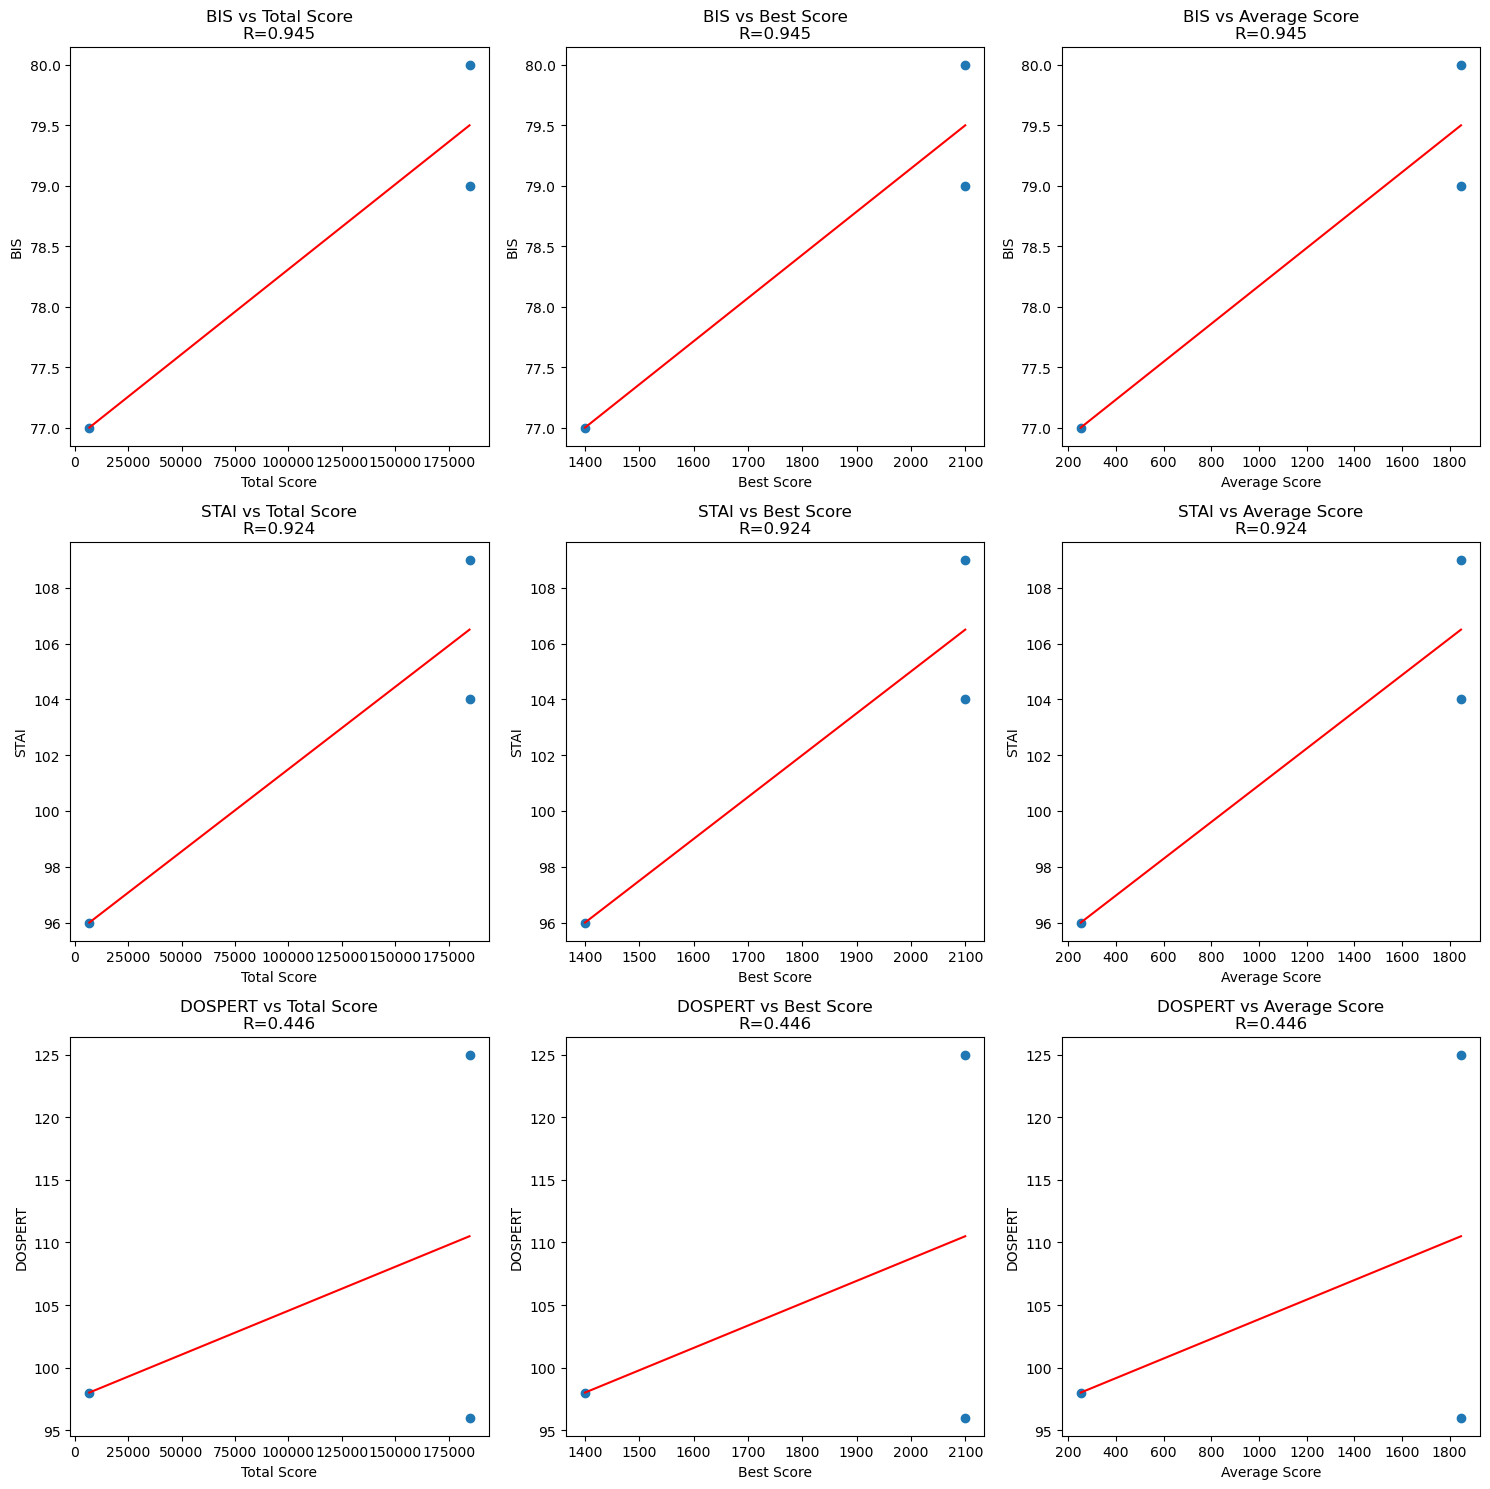

In [16]:
questionnaires = [
    "BIS", # "BIS_motor", "BIS_nonplanning", "BIS_attentional",
    "STAI", # "STAI_S", "STAI_T",
    "DOSPERT", # "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"
]
row_count = len(questionnaires)

fig, axes = plt.subplots(row_count, 3, figsize=(15, 15))
for i in range(row_count):
    questionnaire = questionnaires[i]
    scores = ["total_score_full", "best_score_full", "average_score_full"]
    xlabels = ["Total Score", "Best Score", "Average Score"]
    for j in range(3):
        x = df[scores[j]]
        y = df[questionnaire]

        axes[i, j].scatter(x, y)

        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        line_x = np.linspace(x.min(), x.max(), 100)
        line_y = slope * line_x + intercept
        axes[i, j].plot(line_x, line_y, color="red")
        
        axes[i, j].set_xlabel(xlabels[j])
        axes[i, j].set_ylabel(questionnaire)
        axes[i, j].set_title(f"{questionnaire} vs {xlabels[j]}\nR={r_value:.3f}")

plt.tight_layout()
plt.show()

## TODO

- Traditional Behavior Tasks
- crosswalk usage
- game overs
- Locomotor Statistics
  - action proportions
  - number of visited tiles